# EDA и гипотезы

Посмотрим глубже на наши данные и выведем из полученного анализа гипотезы и проверим их

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,customer_type,adr,total_of_special_requests,stays_in_nights,has_weekend_nights,guests_categories
0,Resort Hotel,0,342,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
1,Resort Hotel,0,737,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
2,Resort Hotel,0,7,2015,July,1,GBR,Direct,Direct,0,0,0,No Deposit,Transient,75.00,0,1,0,Solo
3,Resort Hotel,0,13,2015,July,1,GBR,Corporate,Corporate,0,0,0,No Deposit,Transient,75.00,0,1,0,Solo
4,Resort Hotel,0,14,2015,July,1,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,98.00,1,2,0,Couple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87378,City Hotel,0,23,2017,August,30,BEL,Offline TA/TO,TA/TO,0,0,0,No Deposit,Transient,96.14,0,7,1,Couple
87379,City Hotel,0,102,2017,August,31,FRA,Online TA,TA/TO,0,0,0,No Deposit,Transient,225.43,2,7,1,Group
87380,City Hotel,0,34,2017,August,31,DEU,Online TA,TA/TO,0,0,0,No Deposit,Transient,157.71,>2,7,1,Couple
87381,City Hotel,0,109,2017,August,31,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,104.40,0,7,1,Couple


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87383 entries, 0 to 87382
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87383 non-null  str    
 1   is_canceled                     87383 non-null  int64  
 2   lead_time                       87383 non-null  int64  
 3   arrival_date_year               87383 non-null  int64  
 4   arrival_date_month              87383 non-null  str    
 5   arrival_date_day_of_month       87383 non-null  int64  
 6   country                         87383 non-null  str    
 7   market_segment                  87383 non-null  str    
 8   distribution_channel            87383 non-null  str    
 9   previous_cancellations          87383 non-null  int64  
 10  previous_bookings_not_canceled  87383 non-null  int64  
 11  booking_changes                 87383 non-null  str    
 12  deposit_type                    87383 non-n

## Перейдем к multivariate analysis по данным признакам

### hotel & is_cancelled
Базовое сравнение отелей по успешности, измеряемой таргетом.

In [3]:
df[df['hotel'] == 'City Hotel']['is_canceled'].value_counts()

is_canceled
0    37379
1    16048
Name: count, dtype: int64

In [4]:
city_hotel_canceled_cnt = round(df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)].shape[0] / df[df['hotel'] == 'City Hotel'].shape[0] * 100, 2)

In [5]:
resort_hotel_canceled_cnt = round(df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 1)].shape[0] / df[df['hotel'] == 'Resort Hotel'].shape[0] * 100, 2)

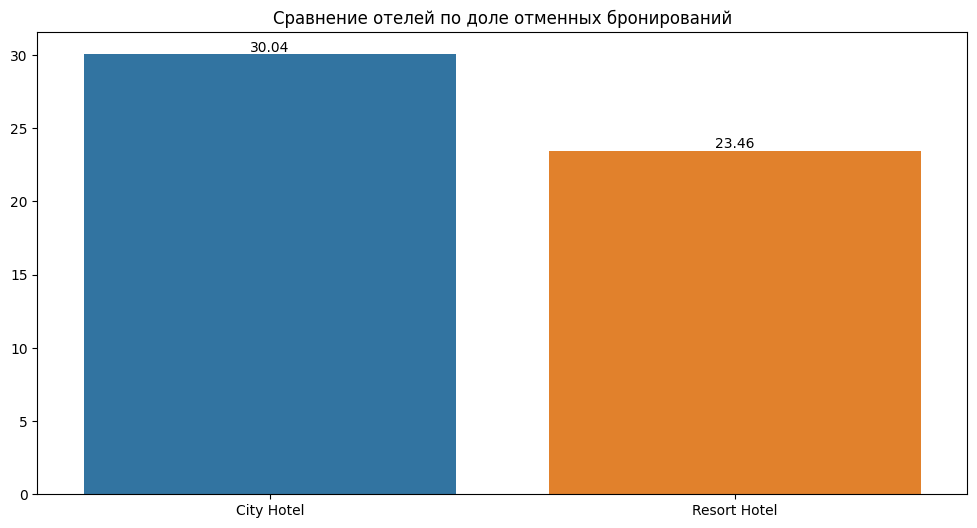

In [6]:
plt.figure(figsize=(12,6))
plt.title('Сравнение отелей по доле отменных бронирований')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot
ax = sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}))
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

В City Hotel доля отмененных бронирований больше, 30% против 23.5%. То есть на первый взгляд Resort Hotel показывает себя лучше, но мы еще далее посмотрим сравнение этих отелей вкупе с другими признаками.

### guests_categories & is_canceled

Посмотрим на то, есть ли различия между разными типами гостей и таргетом

In [7]:
guests_categories = df.groupby('guests_categories').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

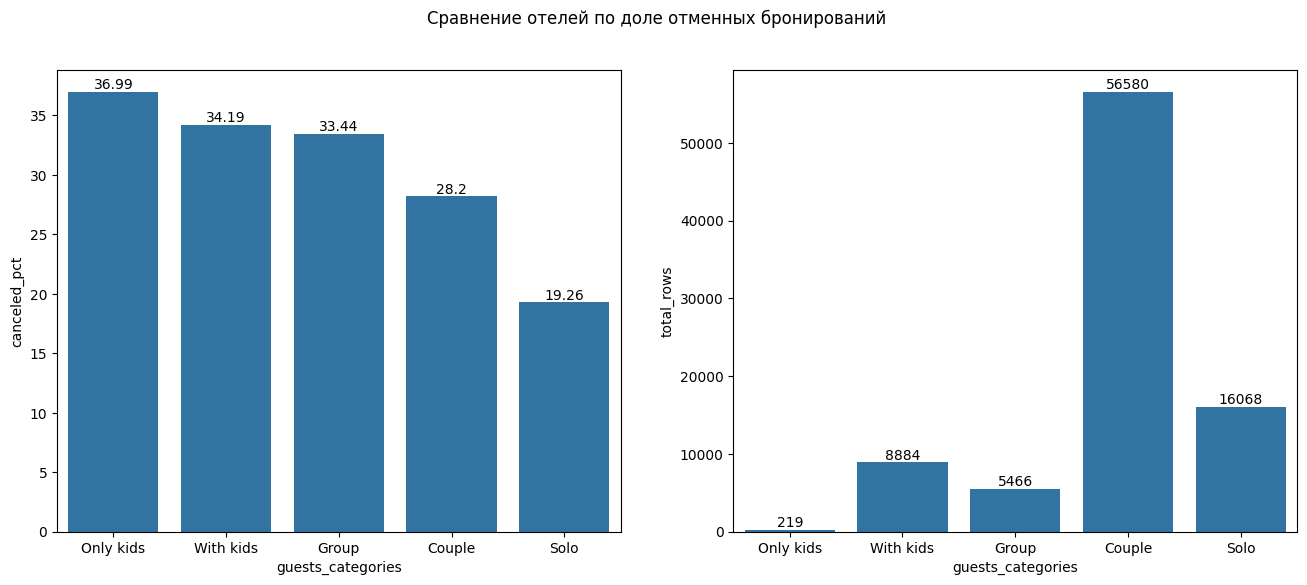

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение отелей по доле отменных бронирований')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне
sns.barplot(guests_categories['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(guests_categories['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Можно заметить, что самая высокая доля отмен у броней только с детьми в виде гостей, но их и самое малое количество. Интереснее тут группы: 1) с одним гостем и 2) гости с детьми. Сольные брони у нас самые успешные по таргету, а с детьми самые неуспешные, не считая очень маленькой "странной" группы - только дети. При этом размеры выборок обе сильно меньше самой популярной группы - пары и между собой не так сильно различимы, хоть и разница примерно в 2 раза по размерам. Так что эту гипотезу можно далее проверить статистически - действительно ли брони с детьми "хуже" сольных бронирований.

### Объединим два наблюдения выше. Посмотрим также сравнение категорий гостей, но дополнительно сравним разные отели

In [9]:
guests_categories = df.groupby(['guests_categories', 'hotel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

In [10]:
guests_categories

total_canceled  total_rows  canceled_pct
guests_categories hotel                                                 
Only kids         City Hotel                81         219         36.99
Group             City Hotel              1643        4452         36.90
With kids         Resort Hotel            1364        3869         35.25
                  City Hotel              1673        5015         33.36
Couple            City Hotel             10375       33412         31.05
                  Resort Hotel            5582       23168         24.09
Solo              City Hotel              2262       10175         22.23
Group             Resort Hotel             185        1014         18.24
Solo              Resort Hotel             832        5893         14.12

In [11]:
hotels_value_counts = df['hotel'].value_counts().reset_index().T
# https://datascientyst.com/how-to-use-the-first-row-as-the-header-in-pandas/
hotels_value_counts.columns = hotels_value_counts.iloc[0]
hotels_value_counts = hotels_value_counts[1:]

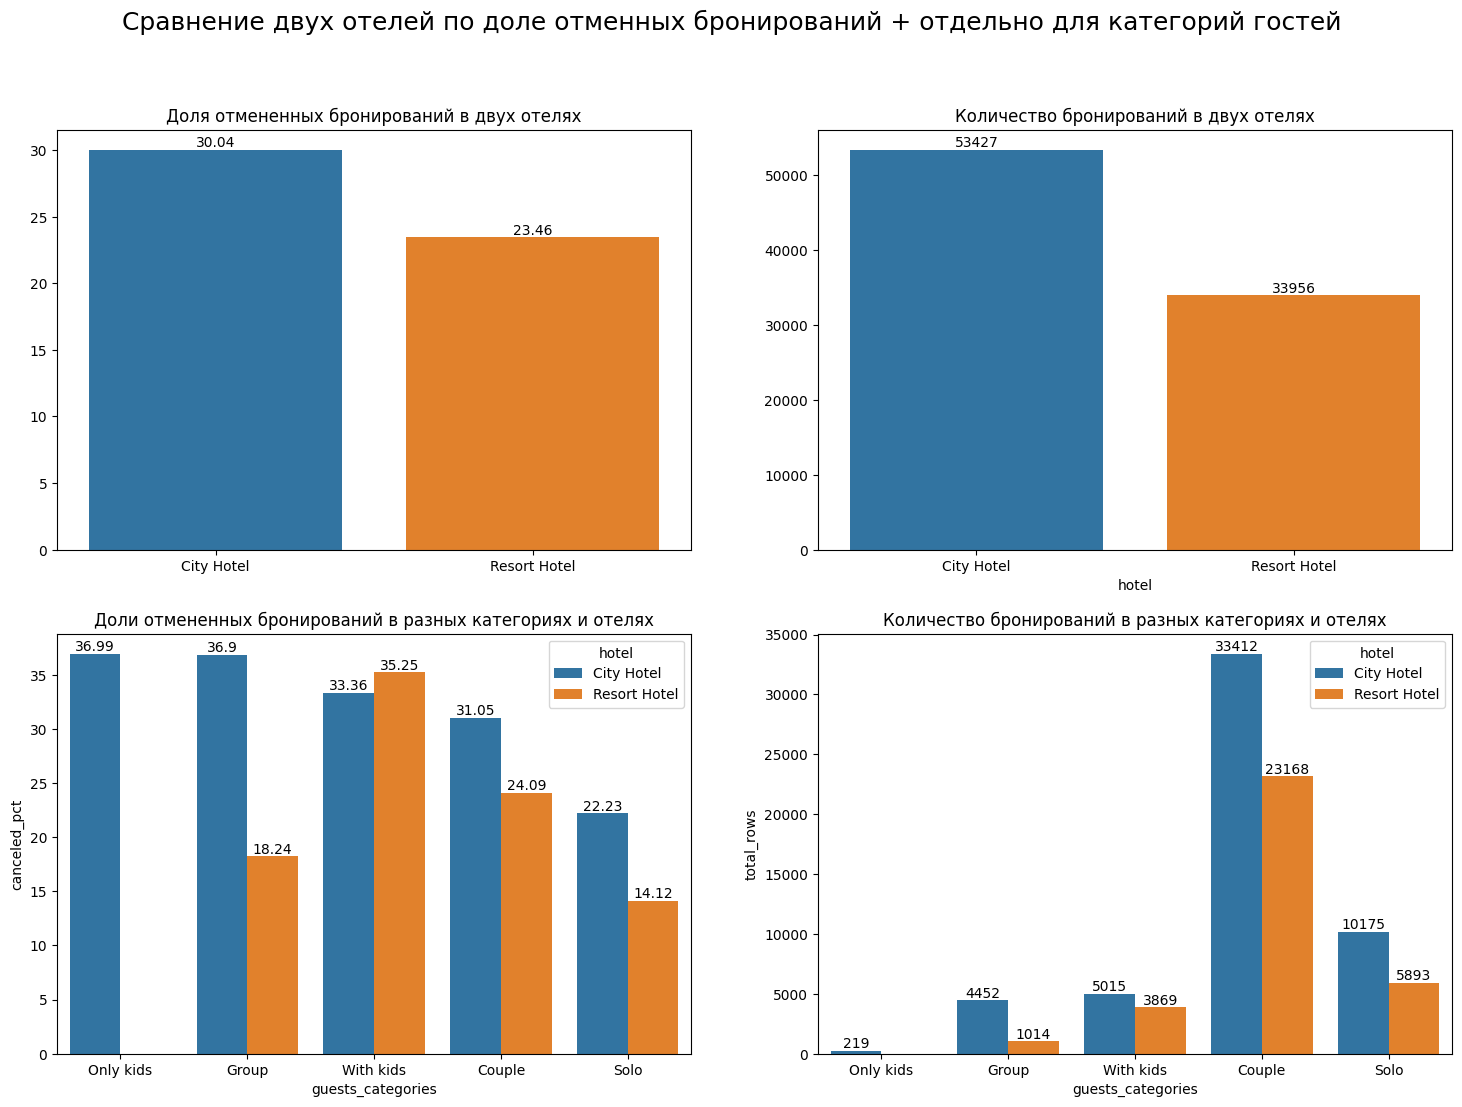

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Сравнение двух отелей по доле отменных бронирований + отдельно для категорий гостей', fontsize='18')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне

sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}), ax=axes[0, 0])
axes[0, 0].set_title('Доля отмененных бронирований в двух отелях')
axes[0, 0].bar_label(axes[0, 0].containers[0])
axes[0, 0].bar_label(axes[0, 0].containers[1])

sns.barplot(hotels_value_counts, ax=axes[0, 1])
axes[0, 1].set_title('Количество бронирований в двух отелях')
axes[0, 1].bar_label(axes[0, 1].containers[0])
axes[0, 1].bar_label(axes[0, 1].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='canceled_pct', hue='hotel', ax=axes[1, 0])
axes[1, 0].set_title('Доли отмененных бронирований в разных категориях и отелях')
axes[1, 0].bar_label(axes[1, 0].containers[0])
axes[1, 0].bar_label(axes[1, 0].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='total_rows', hue='hotel', ax=axes[1, 1])
axes[1, 1].set_title('Количество бронирований в разных категориях и отелях')
axes[1, 1].bar_label(axes[1, 1].containers[0])
axes[1, 1].bar_label(axes[1, 1].containers[1])
plt.show()

Тут добавилось интересное дополнение - категория With kids в обоих отелях примерно с одинаковой долей отмененных броней и с несильно отличающейся выборкой в каждом из отелей, а вот если смотреть на Solo, то в Resort Hotel она показывает себя еще лучше с процентом отмен всего в 14.12%, но бронирований там почти в 2 раза меньше чем в City Hotel. Отсюда выходит еще одна возможная гипотеза о том, что Solo успешнее, причем в одном из отелей, который в целом по всем категориям показывает себя лучше - это еще заметнее и тогда сравнение этих категорий в рамках Resort Hotel, возможно, покажет еще большую уверенность и саму разность групп. Анализ всего этого блока может в итоге дать хорошее наблюдение для отеля - а именно то, какие категории гостей надежнее и в каких отелях это проявляется особенно хорошо или же один отель просто в целом лучше другого и разница между категориями внутри отелей примерно одинаковая. Далее надо подумать над тем, какие гипотезы сформировать лучше всего для получения наиболее полезного результата для бизнеса.

#### guests_categories & (market_segment, distribution_channel)
Посмотрим на то, как об отеле узнают, как бронируют разные категории гостей. Только в этот раз не будем смотреть категории Only kids чтобы не перезагружать полученный "дашборд".

In [13]:
market_segment_in_guests_categories = df.groupby(['guests_categories', 'market_segment']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size')).reset_index()
market_segment_in_guests_categories['canceled_pct'] = round(market_segment_in_guests_categories['total_canceled'] / market_segment_in_guests_categories['total_rows'] * 100, 2)

distribution_channel_in_guests_categories = df.groupby(['guests_categories', 'distribution_channel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size')).reset_index()
distribution_channel_in_guests_categories['canceled_pct'] = round(distribution_channel_in_guests_categories['total_canceled'] / distribution_channel_in_guests_categories['total_rows'] * 100, 2)

distribution_channel_in_guests_categories


,guests_categories,distribution_channel,total_canceled,total_rows,canceled_pct
0,Couple,Corporate,227,1157,19.62
1,Couple,Direct,1181,7844,15.06
2,Couple,Other,8,17,47.06
3,Couple,TA/TO,14541,47562,30.57
4,Group,Corporate,9,61,14.75
5,Group,Direct,93,612,15.20
6,Group,Other,2,2,100.00
7,Group,TA/TO,1724,4791,35.98
8,Only kids,Direct,8,33,24.24
9,Only kids,TA/TO,73,186,39.25


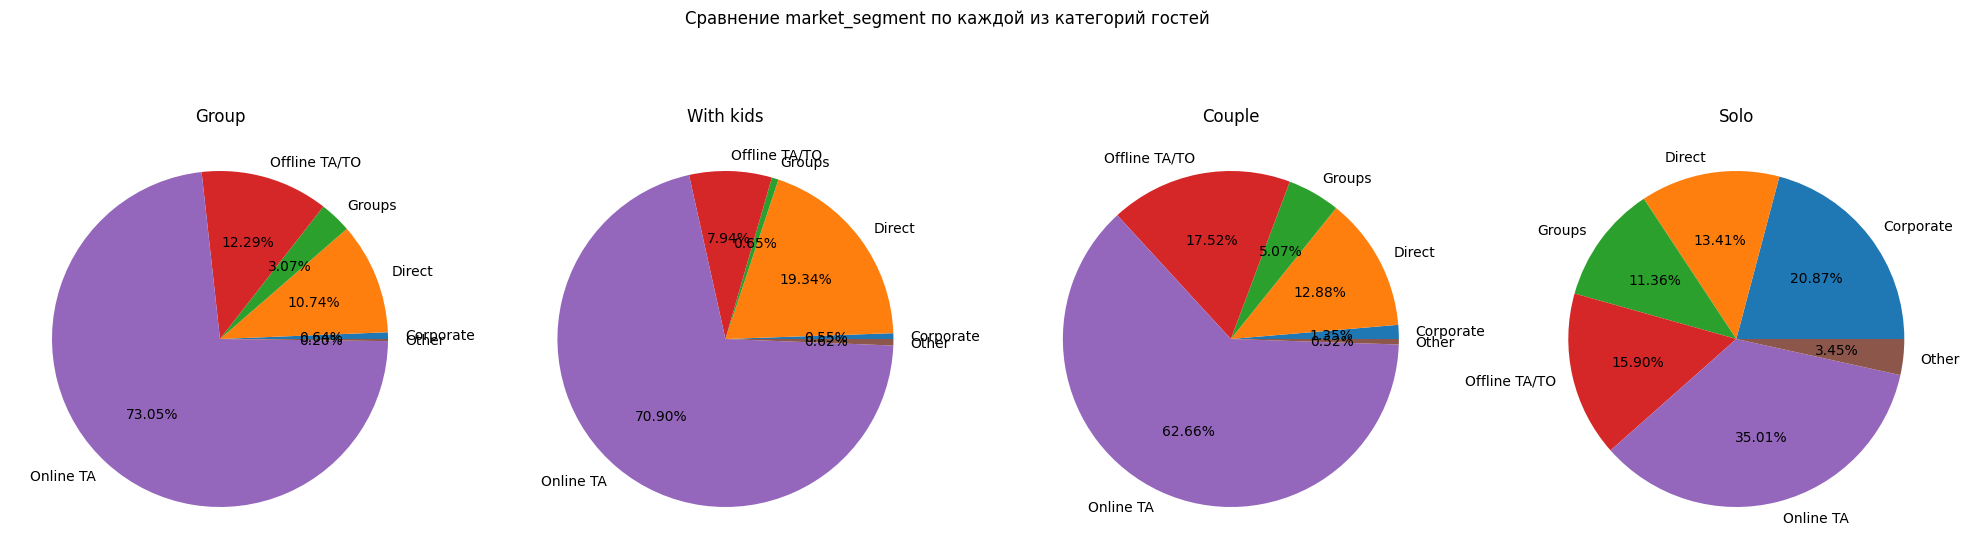

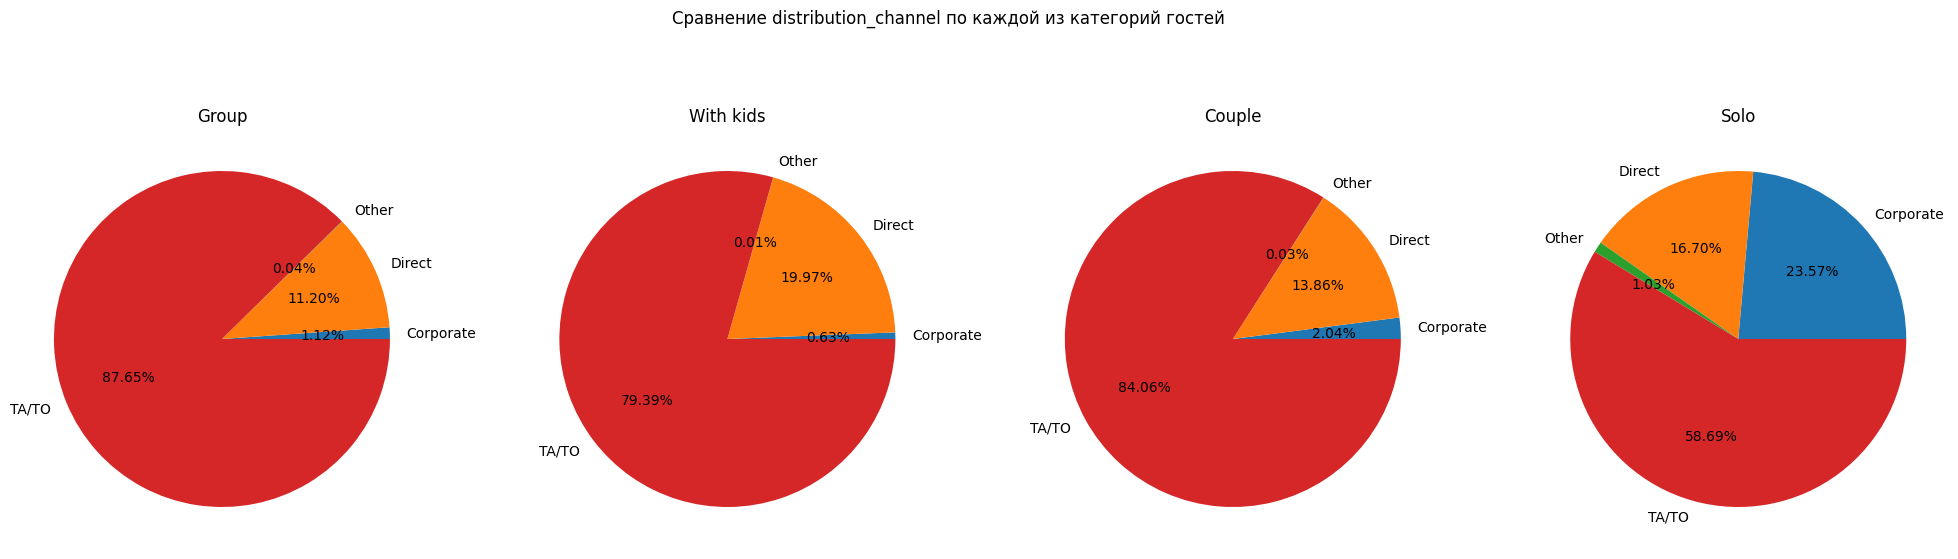

In [14]:
plt.figure(figsize=(25, 12))

plt.suptitle('Сравнение market_segment по каждой из категорий гостей')
plt.subplot(2, 4, 1)

plt.title('Group')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Group']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 2)

plt.title('With kids')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'With kids']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 3)

plt.title('Couple')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Couple']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 4)

plt.title('Solo')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Solo']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.show()

plt.figure(figsize=(25, 12))

plt.suptitle('Сравнение distribution_channel по каждой из категорий гостей')
plt.subplot(2, 4, 1)

plt.title('Group')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Group']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 2)

plt.title('With kids')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'With kids']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 3)

plt.title('Couple')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Couple']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 4)

plt.title('Solo')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Solo']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.show()

Можно заметить, что во всех категориях кроме Solo большая часть бронирований оформляется через тур агентов и тур операторов, причем зачастую онлайн. Но вот у Solo заметно увеличение как категории Corporate, что как будто говорит о том, что это оформляются командировочные для сотрудников, так и Groups, что как будто также говорит о том, что это те же командировки, но групповые. Это предположительно может объяснять низкую долю отмен бронирований, но для этого давайте далее сравним Corporate с другими (возьмем самые основные: TO/TA и Direct) по таргету is_canceled. Пока продолжим смотреть по обоим признакам и по market_segment и по distribution_channel.

In [15]:
market_segments = df.groupby('market_segment').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))
market_segments['canceled_pct'] = round(market_segments['total_canceled'] / market_segments['total_rows'] * 100, 2)
market_segments = market_segments[market_segments.index != 'Other']

distribution_channels = df.groupby('distribution_channel').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))
distribution_channels['canceled_pct'] = round(distribution_channels['total_canceled'] / distribution_channels['total_rows'] * 100, 2)
distribution_channels = distribution_channels[distribution_channels.index != 'Other']

distribution_channels


,total_canceled,total_rows,canceled_pct
distribution_channel,,,
Corporate,648,5081,12.75
Direct,1919,12981,14.78
TA/TO,21406,69135,30.96


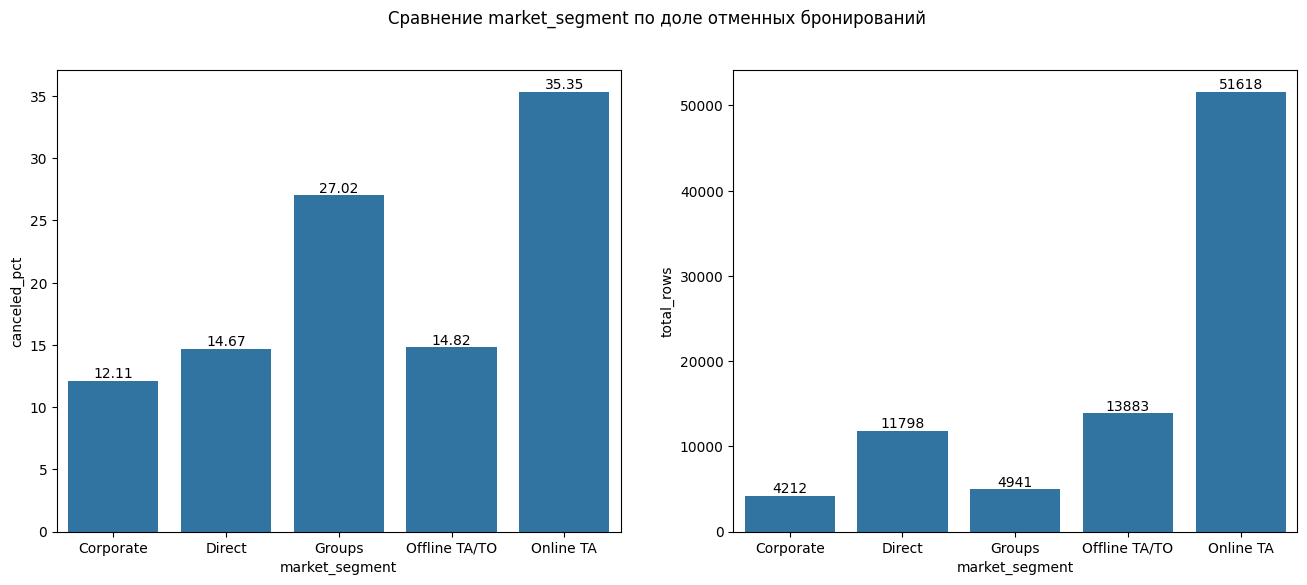

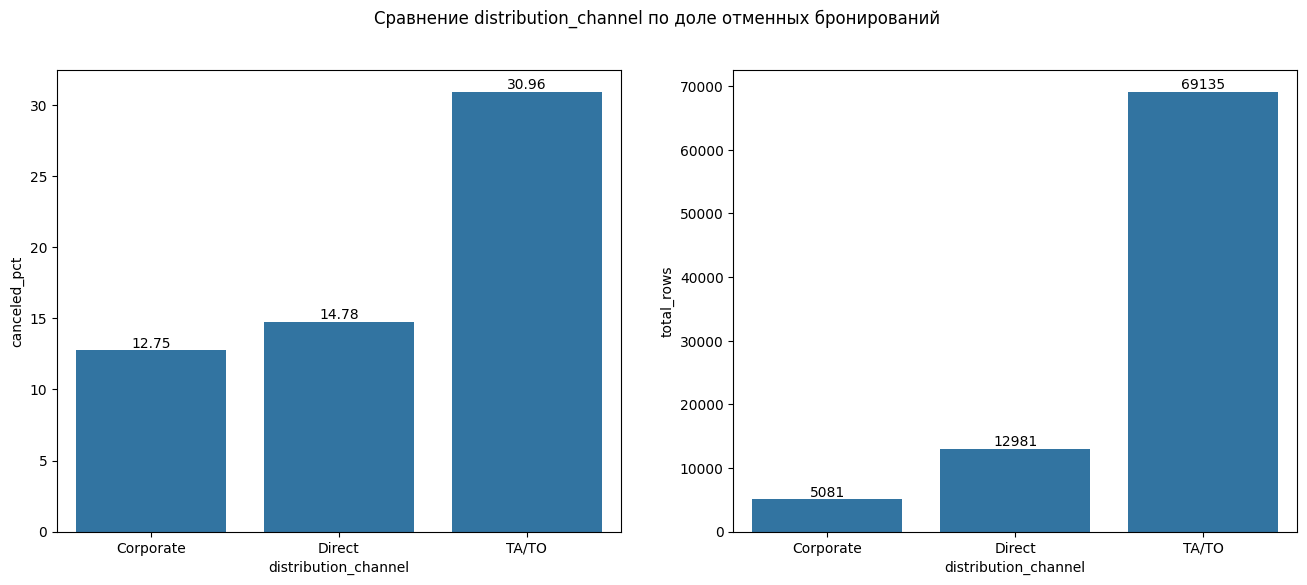

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение market_segment по доле отменных бронирований')

sns.barplot(market_segments['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(market_segments['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение distribution_channel по доле отменных бронирований')

sns.barplot(distribution_channels['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(distribution_channels['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Действительно, у Corporate ниже доля отмен, вот как раз таки у TA/TO сильно выше, но пока статистически это не подтверждено.

Теперь давайте закрепим наше первичное представление о причина успеха Solo и вернемся к графикам с прошлой части анализа но посмотрим все только без Corporate, то есть попробуем так уровнять Solo с другими категориями гостей.

Для начала все используемые датафреймы отфильтруем по новому условию

In [17]:
df_without_corp = df[(df['market_segment'] != 'Corporate') & (df['distribution_channel'] != 'Corporate')]
city_hotel_canceled_cnt = round(df_without_corp[(df_without_corp['hotel'] == 'City Hotel') & (df_without_corp['is_canceled'] == 1)].shape[0] / df_without_corp[df_without_corp['hotel'] == 'City Hotel'].shape[0] * 100, 2)
resort_hotel_canceled_cnt = round(df_without_corp[(df_without_corp['hotel'] == 'Resort Hotel') & (df_without_corp['is_canceled'] == 1)].shape[0] / df_without_corp[df_without_corp['hotel'] == 'Resort Hotel'].shape[0] * 100, 2)

guests_categories = df_without_corp.groupby(['guests_categories', 'hotel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

hotels_value_counts = df_without_corp['hotel'].value_counts().reset_index().T
# https://datascientyst.com/how-to-use-the-first-row-as-the-header-in-pandas/
hotels_value_counts.columns = hotels_value_counts.iloc[0]
hotels_value_counts = hotels_value_counts[1:]

In [18]:
df_without_corp

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,customer_type,adr,total_of_special_requests,stays_in_nights,has_weekend_nights,guests_categories
0,Resort Hotel,0,342,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
1,Resort Hotel,0,737,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
2,Resort Hotel,0,7,2015,July,1,GBR,Direct,Direct,0,0,0,No Deposit,Transient,75.00,0,1,0,Solo
4,Resort Hotel,0,14,2015,July,1,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,98.00,1,2,0,Couple
5,Resort Hotel,0,0,2015,July,1,PRT,Direct,Direct,0,0,0,No Deposit,Transient,107.00,0,2,0,Couple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87378,City Hotel,0,23,2017,August,30,BEL,Offline TA/TO,TA/TO,0,0,0,No Deposit,Transient,96.14,0,7,1,Couple
87379,City Hotel,0,102,2017,August,31,FRA,Online TA,TA/TO,0,0,0,No Deposit,Transient,225.43,2,7,1,Group
87380,City Hotel,0,34,2017,August,31,DEU,Online TA,TA/TO,0,0,0,No Deposit,Transient,157.71,>2,7,1,Couple
87381,City Hotel,0,109,2017,August,31,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,104.40,0,7,1,Couple


А далее построим тот же график.

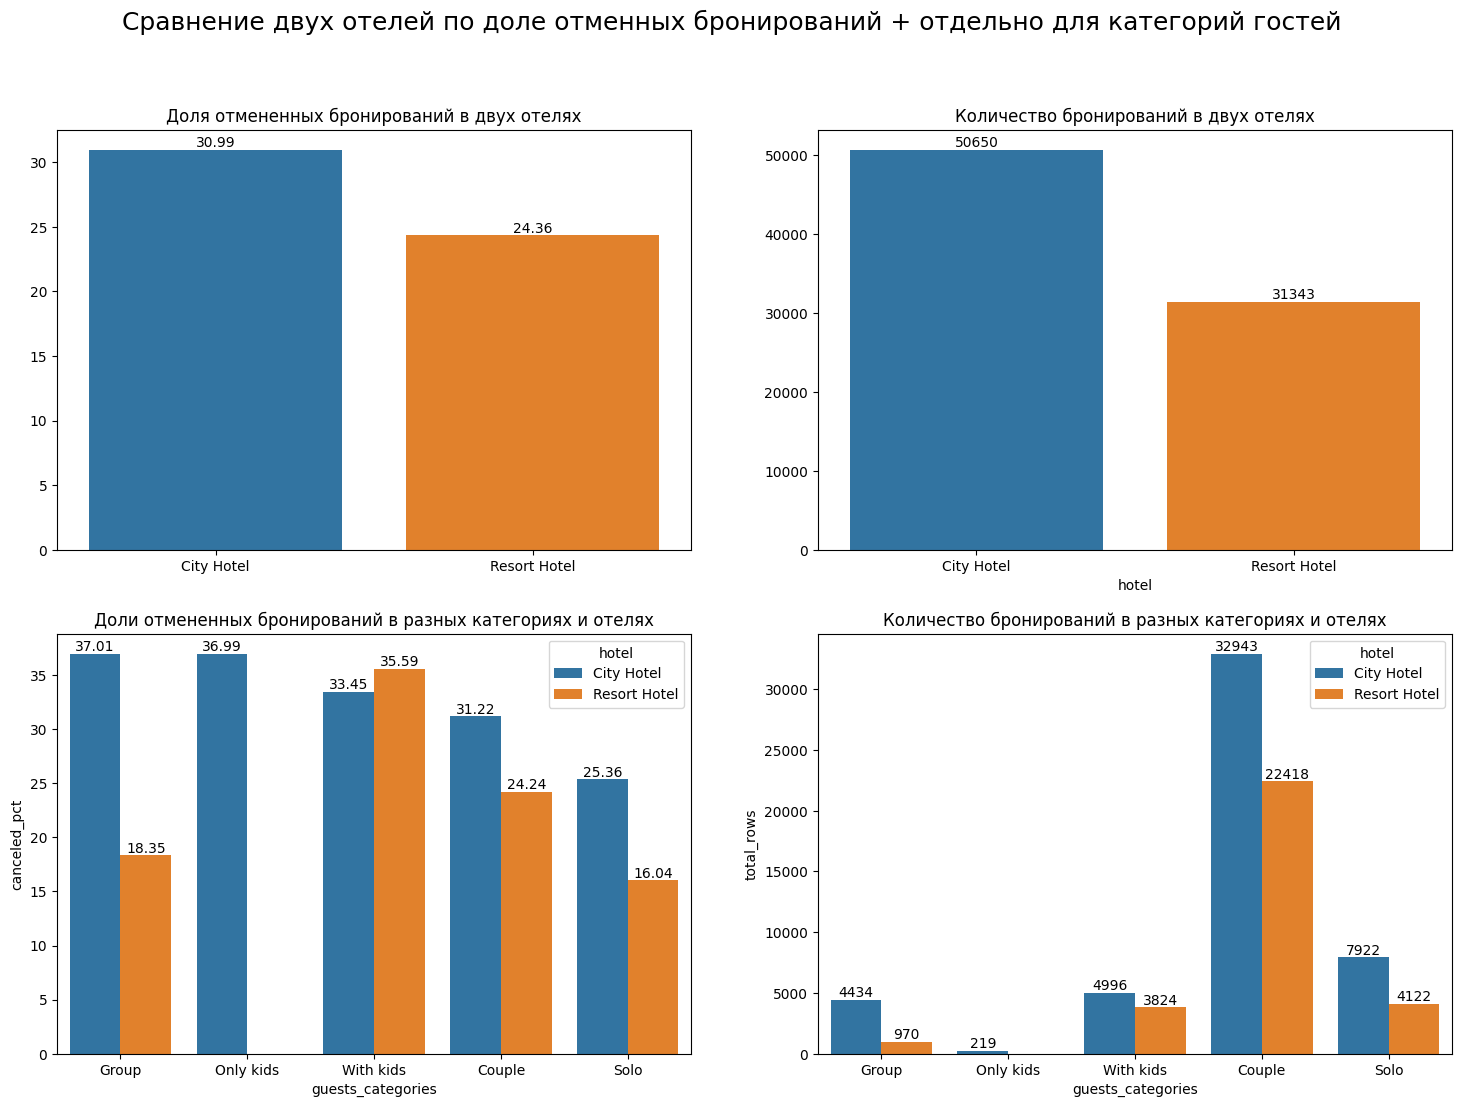

In [19]:


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Сравнение двух отелей по доле отменных бронирований + отдельно для категорий гостей', fontsize='18')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне

sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}), ax=axes[0, 0])
axes[0, 0].set_title('Доля отмененных бронирований в двух отелях')
axes[0, 0].bar_label(axes[0, 0].containers[0])
axes[0, 0].bar_label(axes[0, 0].containers[1])

sns.barplot(hotels_value_counts, ax=axes[0, 1])
axes[0, 1].set_title('Количество бронирований в двух отелях')
axes[0, 1].bar_label(axes[0, 1].containers[0])
axes[0, 1].bar_label(axes[0, 1].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='canceled_pct', hue='hotel', ax=axes[1, 0])
axes[1, 0].set_title('Доли отмененных бронирований в разных категориях и отелях')
axes[1, 0].bar_label(axes[1, 0].containers[0])
axes[1, 0].bar_label(axes[1, 0].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='total_rows', hue='hotel', ax=axes[1, 1])
axes[1, 1].set_title('Количество бронирований в разных категориях и отелях')
axes[1, 1].bar_label(axes[1, 1].containers[0])
axes[1, 1].bar_label(axes[1, 1].containers[1])
plt.show()

Вывыдем отдельно еще данные с прошлого графика:

In [20]:
print(f'Доля отмененных бронирований в Resort Hotel: 24.36% (23.46% - без Corporate)')
print(f'Доля отмененных бронирований в Resort Hotel для Solo: 16.04% (14.12% - без Corporate)\n')

print(f'Доля отмененных бронирований в City Hotel: 30.99% (30.04% - без Corporate)')
print(f'Доля отмененных бронирований в City Hotel для Solo: 25.36% (22.23% - без Corporate)')

Доля отмененных бронирований в Resort Hotel: 24.36% (23.46% - без Corporate)
Доля отмененных бронирований в Resort Hotel для Solo: 16.04% (14.12% - без Corporate)

Доля отмененных бронирований в City Hotel: 30.99% (30.04% - без Corporate)
Доля отмененных бронирований в City Hotel для Solo: 25.36% (22.23% - без Corporate)


В Resort Hotel с новым фильтром доля отменных бронирований выросла, но также произошла и для City Hotel, так что на первый взгляд говорить, что Corporate "завышвает" результаты для Resort Hotel нельзя, но можно сказать, что сказывается отдельно на категории Solo, хотя даже так она сильно лучше остальных, о чем мы говорили по прошлому графику